# 전처리 & 머신러닝 통합 개인과제

## Part 3. 구매 가능 고객 예측

### 실무 시나리오

전자상거래 기업의 CRM팀은 모든 고객에게 동일한 프로모션을 제공하면서 마케팅 비용이 증가하고 있습니다.  
데이터 분석팀은 Part 1에서 정비한 고객 데이터와 Part 2에서 확인한 구매 특성을 활용하여 **구매 가능성이 높은 고객을 선별하는 예측 모델**을 개발하려고 합니다.

수강생은 데이터 분석 담당자로서 다음 업무를 수행합니다.

1. 구매 여부 예측 문제와 모델링 데이터를 정의합니다.
2. 기본 분류 모델을 개발하고 성능을 평가합니다.
3. 모델을 조정한 뒤 기본 모델과 비교하고 과적합 여부를 진단합니다.

> 문제 1~3은 필수 문제입니다.  
> 문제 4는 추가 모델 검토를 위한 심화 문제이며 선택적으로 수행합니다.

## 과제 목표

- 구매 여부 예측 문제를 분류 문제로 정의하고 적절한 입력 변수와 타깃 변수를 구성할 수 있습니다.
- 수치형·범주형 데이터에 필요한 전처리를 적용하여 기본 분류 모델을 학습할 수 있습니다.
- Accuracy, Precision, Recall, F1-score와 혼동행렬을 활용하여 모델 성능을 평가할 수 있습니다.
- 기본 모델과 개선 모델의 학습·검증 성능을 비교하여 성능 개선과 과적합 여부를 판단할 수 있습니다.

## 사용 환경 및 데이터

- Python 3.X
- pandas, numpy
- `전자상거래_고객구매_전처리완료.csv`

# 문제 1. 예측 문제와 학습 데이터 구성

## 업무 상황

CRM팀은 고객의 현재 정보를 바탕으로 구매 가능성이 높은 고객을 구분하려고 합니다.  
모델 개발 전에 예측 대상과 입력 변수를 정하고, 실제 예측 시점에 사용할 수 없는 정보가 포함되지 않았는지 확인해야 합니다.

## 필수 요구사항

1. 전처리 완료 데이터를 불러오고 데이터 크기와 주요 컬럼을 확인하세요.
2. `PurchaseStatus`의 클래스별 개수와 비율을 확인하세요.
3. 해당 예측 과제가 분류 문제인지 회귀 문제인지 작성하세요.
4. 타깃 변수 `y`와 입력 변수 `X`를 구성하세요.
5. 고객 식별 정보와 예측에 적절하지 않은 변수를 제외하세요.
6. 학습 데이터와 검증 데이터를 분리하세요.

### 힌트

- 고객을 직접 식별하는 컬럼은 일반적인 구매 행동 패턴 학습에 적절하지 않을 수 있습니다.
- 날짜는 그대로 사용하기보다 기준일과의 차이를 수치로 변환할 수 있습니다.
- 클래스 비율을 유지하면서 데이터를 분리하는 방법을 생각해보세요.

In [56]:
import pandas as pd
import numpy as np

DATA_PATH = "전자상거래_고객구매_전처리완료.csv"

# TODO: 데이터를 불러오고 기본 구조를 확인하세요.
df = pd.read_csv(DATA_PATH)

In [57]:
# TODO: 날짜형 변수를 활용하여 필요한 파생변수를 생성하세요.
# TODO: 입력 변수 X와 타깃 변수 y를 구성하세요.
# TODO: 식별 정보 및 예측 시점에 부적절한 변수를 제외하세요.

# 사용할 데이터
model_df = df[['VisitCount', 'AveragePurchaseAmount', 'SatisfactionScore', 'RecenctPurchaseDays', 'SignedDays', 'AmountPerVisit',
                'Gender', 'Region', 'MembershipLevel', 'CouponUsed', 'PreferredCategory', 'AgeGroup', 'PurchaseGrade',
                'PurchaseStatus']]
# 독립변수
X = model_df.drop(columns = ['PurchaseStatus'])

# 종속변수
y = model_df['PurchaseStatus']

print('예측 데이터 전체 구조 :', model_df.shape)
print('독립변수 구조 :', X.shape)
print('종속변수 구조 :', y.shape)


예측 데이터 전체 구조 : (1465, 14)
독립변수 구조 : (1465, 13)
종속변수 구조 : (1465,)


In [58]:
from sklearn.model_selection import train_test_split

# TODO: 학습 데이터와 검증 데이터를 분리하세요.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 만약  y가 2차원 배열이면 squeeze() ( - 데이터프레임을 1차원으로 변경 짜줌) 필요

print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(1172, 13) (293, 13) (1172,) (293,)


### 문제 1 결과 작성

- 문제 유형: 종속변수인 `PurchaseStatus`의 구매 여부에 대해 분류하는 문제

- 타깃 변수의 의미: 구매 여부 (0 - 미구매, 1 - 구매)

- 사용한 주요 입력 변수:   
['VisitCount', 'AveragePurchaseAmount', 'SatisfactionScore', 'RecenctPurchaseDays', 'SignedDays', 'AmountPerVisit',
'Gender', 'Region', 'MembershipLevel', 'CouponUsed', 'PreferredCategory', 'AgeGroup', 'PurchaseGrade']

- 제외한 변수:   
['CustomerID', 'Email', 'Age', 'LastPurchaseDate', 'SignupDate', 'PurchaseStatus', 'TotalPurchaseAmount']

- 학습·검증 데이터 크기:
    - 학습 데이터 : 1172개
    - 검증 데이터 : 293개

- 클래스 비율을 유지하여 분리한 이유: 학습데이터에만 맞춘 과적합하지않기 위해 

# 문제 2. 기본 구매예측 모델 개발 및 평가

## 업무 상황

CRM팀은 먼저 복잡하지 않고 결과를 설명하기 쉬운 기본 모델을 구축하려고 합니다.  
분석 담당자는 수치형·범주형 변수에 필요한 전처리를 적용하고, 구매 여부를 예측하는 기본 분류 모델을 학습해야 합니다.

## 필수 요구사항

1. 수치형 변수와 범주형 변수를 구분하세요.
2. 각 변수 유형에 필요한 결측치 처리와 변환을 적용하세요.
3. 전처리 과정과 분류 모델이 연결되도록 기본 모델을 구성하세요.
4. 검증 데이터에 대한 예측 결과를 생성하세요.
5. Accuracy, Precision, Recall, F1-score를 계산하세요.
6. 혼동행렬을 확인하세요.
7. 사용한 기본 분류 모델을 제시하고, 해당 모델이 구매 여부 예측 문제에 적합한 이유를 작성하세요.
8. CRM 업무 목적을 고려하여 중요하게 볼 평가 지표를 하나 선택하고 이유를 작성하세요.

### 힌트

- 수치형 변수에는 대표값 대체와 스케일링을 적용할 수 있습니다.
- 범주형 변수에는 대표값 대체와 One-Hot Encoding을 적용할 수 있습니다.
- 기본 모델로 Logistic Regression을 사용할 수 있습니다.

In [59]:
display(X.head(3))

,VisitCount,AveragePurchaseAmount,SatisfactionScore,RecenctPurchaseDays,SignedDays,AmountPerVisit,Gender,Region,MembershipLevel,CouponUsed,PreferredCategory,AgeGroup,PurchaseGrade
0,5,75000.0,3.7,114,1276,27960,F,Seoul,Silver,N,Beauty,40,1
1,7,74400.0,4.8,40,1781,22742,M,Gyeonggi,Basic,N,Home,30,1
2,7,153900.0,4.5,25,1678,59028,M,Daegu,Vip,N,Home,40,2


In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt
import seaborn as sns
%config InlineBackend.figure_format = 'retina'


# TODO: 수치형·범주형 변수를 구분하세요.
numeric_features = ['VisitCount', 'AveragePurchaseAmount', 'SatisfactionScore', 'RecenctPurchaseDays', 'SignedDays', 'AmountPerVisit']
categorical_features = ['Gender', 'Region', 'MembershipLevel', 'CouponUsed', 'PreferredCategory', 'AgeGroup', 'PurchaseGrade'] # 'AgeGroup', 'PurchaseGrade'은 범주형 변수이지만 수치로 나타나있음

# TODO: 전처리기와 기본 모델 Pipeline을 구성하세요.
# Pipeline = 여러 처리 단계를 순서대로 묶어서 한 번에 실행하게 해주는 함수

# 1. 수치형 전처리
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')), # 만약 결측치가 존재하면 중앙값으로 채우기
    ('scaler', StandardScaler()) # 정규화
])

# 2. 범주형 전처리
categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')), # 만약 결측치가 존재하면 최빈값으로 채우기
    ('encoder', OneHotEncoder(handle_unknown='ignore')) # handle_unknown='ignore' - 인코딩한 값을 bool이 아닌 int로 변경
])

# 3. 전처리 합치기
preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numeric_features), # numeric_features에 들어있는 컬럼들에게 numeric_transformer를 적용
    ('cat', categorical_transformer, categorical_features) # categorical_features에 들어있는 컬럼들에게 categorical_transformer를 적용
])

# 4. 전처리 + 기본 모델
baseline_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(random_state=42))
])

# 5. 모델 학습
baseline_model.fit(X_train, y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

Accuracy : 0.73
Precision: 0.736
Recall   : 0.679
F1-score : 0.706


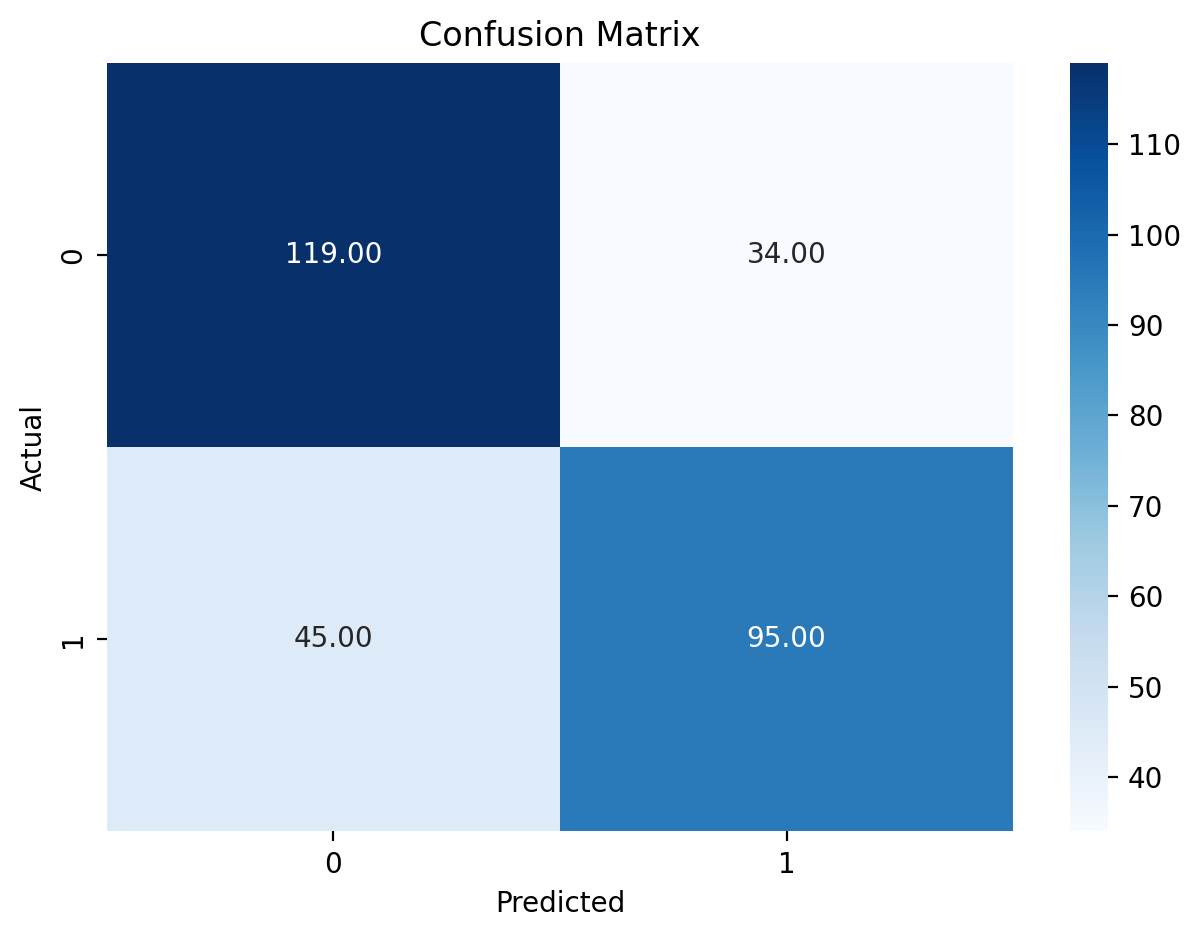

In [61]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt

# TODO: 기본 모델을 학습하고 검증 데이터를 예측하세요.
y_pred = baseline_model.predict(X_test)

# TODO: 주요 평가 지표를 계산하고 혼동행렬을 확인하세요.

print('Accuracy :', round(accuracy_score(y_test, y_pred), 3))
print('Precision:', round(precision_score(y_test, y_pred), 3))
print('Recall   :', round(recall_score(y_test, y_pred), 3))
print('F1-score :', round(f1_score(y_test, y_pred), 3))


# 혼동행렬
matrix = confusion_matrix(y_test, y_pred)
sns.heatmap(matrix, annot=True, fmt = '.2f', cmap='Blues')

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')

plt.tight_layout()
plt.show()

### 문제 2 결과 작성

- 기본 모델: LogisticRegression

- 기본 모델 선택 이유:

- 수치형 변수 전처리: 
    - 결측치가 존재하면 중앙값으로 대체하며, 
    - StandardScaler을 사용하여 단위가 다른 변수들을 평균을 0, 분산을 1로 변환하여 표준화 진행

- 범주형 변수 전처리: 
    - 결측치가 존재하면 최빈값으로 대체하며, 
    - OneHotEncoder를 사용하여 범주형 변수를 모델이 학습할 수 있게 수치형 변수로 변경

- Accuracy : 0.73
- Precision: 0.736
- Recall   : 0.679
- F1-score : 0.706

- 중요하게 선택한 평가 지표와 이유: $$ \mathrm{Recall}=\frac{TP}{TP+FN} $$



    - Recall을 중요 평가 지표로 선택
    - 이유는 실제 구매 가능성이 있는 고객을 최대한 놓치지 않고 찾아내는 것이 중요하다고 판단. Recall이 높을수록 실제 구매 고객 중 모델이 구매 고객이라고 올바르게 예측한 비율이 높아진다.

- 혼동행렬에서 확인한 주요 오분류:
    - 1종 오류(실제로 구매했는데 구매하지 않았다고 오분류)인 34건 
    - 2종 오류(실제로 구매를 안했는데 구매를 했다고 오분류)인 45건
    - 2종 오류는 실제 구매 가능성이 있는 고객을 놓치는 오류이기 때문에 치명적인 오류라고 판단된다.

# 문제 3. 모델 개선 및 최종 모델 선택

## 업무 상황

기본 모델의 결과를 확인한 CRM팀은 모델을 실제 캠페인 대상 선정에 활용할 수 있는지 검토하려고 합니다.  
분석 담당자는 모델 설정을 조정하여 개선 모델을 만들고, 기본 모델과 성능을 비교한 뒤 과적합 여부를 확인해야 합니다.

## 필수 요구사항

1. 기본 모델의 학습 성능과 검증 성능을 계산하세요.
2. 규제 강도 또는 클래스 가중치 등의 설정을 조정하여 개선 모델을 개발하세요.
3. 개선 모델의 학습 성능과 검증 성능을 계산하세요.
4. 기본 모델과 개선 모델의 성능 비교표를 작성하세요.
5. 학습 F1-score와 검증 F1-score의 차이를 확인하여 과적합 여부를 진단하세요.
6. 검증 성능과 과적합 정도를 함께 고려하여 최종 모델을 선택하세요.
7. 학습·검증 성능 차이가 발생한 원인을 설명하고, 적용한 규제 또는 하이퍼파라미터 조정이 성능과 과적합에 어떤 영향을 주었는지 작성하세요.
8. 개선 모델의 성능이 높아지지 않았다면 그 결과도 그대로 비교하고 설명하세요.
9. 최종 모델의 성능상 한계 또는 실제 업무 적용 시 주의할 점을 한 가지 이상 작성하세요.

### 힌트

- Logistic Regression의 규제 강도 또는 `class_weight`를 조정할 수 있습니다.
- 학습 성능이 높더라도 검증 성능과의 차이가 크면 과적합 가능성이 있습니다.
- 개선 모델이 반드시 기본 모델보다 좋아야 하는 것은 아닙니다.

In [62]:
# TODO: 조정한 설정을 적용하여 개선 모델을 구성하고 학습하세요.
improved_model = None

In [63]:
# TODO: 기본 모델과 개선 모델의 학습·검증 성능을 비교하세요.
# 권장 지표: Accuracy, Precision, Recall, F1-score, Train F1 - Validation F1

comparison_df = None

### 문제 3 결과 작성

- 조정한 모델 설정:
- 기본 모델 검증 F1-score:
- 개선 모델 검증 F1-score:
- 기본 모델 학습·검증 차이:
- 개선 모델 학습·검증 차이:
- 과적합 진단:
- 학습·검증 성능 차이의 원인:
- 규제 또는 하이퍼파라미터 조정의 효과:
- 최종 선택 모델:
- 최종 모델 선택 이유:
- 모델 활용 방안:
- 최종 모델의 한계 또는 업무 적용 시 주의점:


# (심화)문제 4. 모델 운영을 위한 추가 검토

## 업무 상황

CRM팀은 기본 모델과 개선 모델의 비교 결과를 확인한 뒤, 실제 캠페인에 모델을 적용하기 전에 모델 성능을 추가로 검증하고 운영 기준을 검토하려고 합니다.

## 요구사항

### 4-1. 추가 모델 비교

1. 기본 모델과 다른 특성을 가진 분류 모델을 한 개 추가로 학습하세요.
2. 동일한 검증 데이터를 사용하여 Accuracy, Precision, Recall, F1-score를 계산하세요.
3. 기존 모델과 추가 모델의 성능 및 해석 가능성을 비교하세요.

### 4-2. 교차검증을 활용한 하이퍼파라미터 탐색

1. 교차검증 또는 `GridSearchCV`를 활용하여 여러 하이퍼파라미터 조합을 비교하세요.
2. 최적 하이퍼파라미터와 교차검증 성능을 확인하세요.
3. 최적 모델의 검증 성능을 기본 모델 및 개선 모델과 비교하세요.

### 4-3. 예측 기준값과 오분류 비용 검토

1. 예측 확률의 기준값을 변경하여 Precision과 Recall의 변화를 확인하세요.
2. CRM 캠페인에서 False Positive와 False Negative가 각각 어떤 비용 또는 기회 손실을 발생시키는지 설명하세요.
3. 업무 목적에 적합한 예측 기준값을 제안하세요.

### 힌트

- 추가 모델로 Decision Tree 등을 사용할 수 있습니다.
- 예측 기준값을 낮추면 일반적으로 Recall이 높아지고, 높이면 Precision이 높아질 수 있습니다.
- 심화 문제는 선택 사항이며 수행하지 않아도 필수 문제 제출에는 문제가 없습니다.


In [64]:
# 심화 문제 4-1
# TODO: 기본 모델과 다른 분류 모델을 추가로 학습하고 성능을 비교하세요.
additional_model = None

In [65]:
# 심화 문제 4-2
# TODO: 교차검증 또는 GridSearchCV로 하이퍼파라미터를 탐색하세요.
search_result = None

In [66]:
# 심화 문제 4-3
# TODO: 예측 기준값별 Precision, Recall, F1-score를 비교하세요.
threshold_result = None


## 심화 문제 결과 작성

### 4-1. 추가 모델 비교

- 추가한 모델:
- 추가 모델을 선택한 이유:
- 기존 모델과의 성능 비교:
- 해석 가능성 및 복잡도 비교:

### 4-2. 하이퍼파라미터 탐색

- 탐색한 하이퍼파라미터:
- 최적 하이퍼파라미터:
- 교차검증 성능:
- 검증 데이터 성능:
- 기존 모델과의 비교 결과:

### 4-3. 예측 기준값과 오분류 비용

- 비교한 예측 기준값:
- 기준값별 Precision과 Recall 변화:
- False Positive의 업무 비용:
- False Negative의 업무 비용:
- 제안하는 최종 기준값과 이유:



# 제출 전 체크리스트

## 필수 체크리스트

- [ ] 구매 여부 예측 문제를 분류 문제로 정의했습니다.
- [ ] 입력 변수와 타깃 변수를 구성했습니다.
- [ ] 식별 정보와 예측에 부적절한 변수를 제외했습니다.
- [ ] 학습 데이터와 검증 데이터를 분리했습니다.
- [ ] 수치형·범주형 전처리를 적용했습니다.
- [ ] 기본 분류 모델을 학습했습니다.
- [ ] 사용한 기본 모델이 구매 여부 예측에 적합한 이유를 작성했습니다.
- [ ] Accuracy, Precision, Recall, F1-score와 혼동행렬을 확인했습니다.
- [ ] 모델 설정을 조정하여 개선 모델을 만들었습니다.
- [ ] 기본 모델과 개선 모델의 성능을 비교했습니다.
- [ ] 학습·검증 성능을 비교하여 과적합 여부를 진단했습니다.
- [ ] 학습·검증 성능 차이의 원인과 모델 조정 효과를 설명했습니다.
- [ ] 최종 모델을 선택하고 이유를 작성했습니다.
- [ ] 최종 모델의 한계 또는 실제 업무 적용 시 주의점을 작성했습니다.

## 심화 체크리스트

- [ ] 다른 분류 모델을 추가로 학습하고 비교했습니다.
- [ ] 교차검증 또는 GridSearchCV를 적용했습니다.
- [ ] 예측 기준값에 따른 Precision과 Recall 변화를 확인했습니다.
- [ ] False Positive와 False Negative의 업무 비용을 설명했습니다.
- [ ] 업무 목적에 적합한 예측 기준값을 제안했습니다.
